<a href="https://colab.research.google.com/github/dishanth2k6/Company-Projects/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
import io


uploaded = files.upload()


file_name = list(uploaded.keys())[0]
print(f"\nSuccessfully uploaded: {file_name}")

Saving housing.csv to housing.csv

Successfully uploaded: housing.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("Regression libraries imported successfully!")

Regression libraries imported successfully!


In [5]:
# Load dataset from memory buffer
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# 1. Handle Missing Values
if df['total_bedrooms'].isnull().sum() > 0:
    df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

# 2. Convert Categorical Values ('ocean_proximity') into numbers using One-Hot Encoding
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

print("Data cleaning & encoding complete. Dataset Shape:", df.shape)
df.head()

Data cleaning & encoding complete. Dataset Shape: (20640, 13)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


In [7]:
# Separate features and target
X = df.drop(columns=['median_house_value'])
y = df['median_house_value']

# Split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale all numerical parameters
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data successfully split and scaled!")

Data successfully split and scaled!


In [8]:
# Initialize models
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Train models
print("Training Linear Regression...")
lr.fit(X_train_scaled, y_train)

print("Training Random Forest Regressor (This might take a moment)...")
rf.fit(X_train_scaled, y_train)

print("Training XGBoost Regressor...")
xgb.fit(X_train_scaled, y_train)

print("All regression models are fully trained!")

Training Linear Regression...
Training Random Forest Regressor (This might take a moment)...
Training XGBoost Regressor...
All regression models are fully trained!


In [9]:
models = {'Linear Regression': lr, 'Random Forest': rf, 'XGBoost': xgb}

for name, model in models.items():
    preds = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"=== {name} ===")
    print(f"RMSE: ${rmse:,.2f}")
    print(f"R² Score: {r2:.4f}\n")

=== Linear Regression ===
RMSE: $70,060.52
R² Score: 0.6254

=== Random Forest ===
RMSE: $49,008.79
R² Score: 0.8167

=== XGBoost ===
RMSE: $48,655.59
R² Score: 0.8193



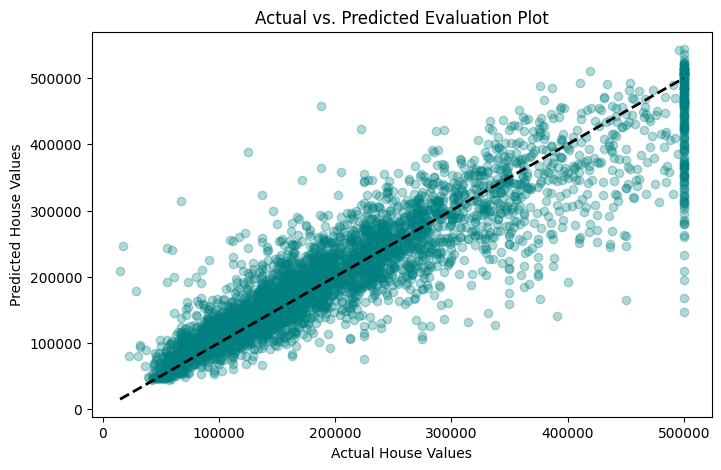

In [10]:
# Grab predictions from XGBoost for example plotting
best_preds = xgb.predict(X_test_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(y_test, best_preds, alpha=0.3, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual House Values')
plt.ylabel('Predicted House Values')
plt.title('Actual vs. Predicted Evaluation Plot')
plt.show()